# Examples

Let’s now do some examples of how to use Qibosoq. Note that, for these examples to be run, the Qibosoq server needs to be running and reachable from the client.

A standard program will be executed with something like:

In [1]:
import json
import socket

HOST = "192.168.1.68"
PORT = 6000

In [2]:
# Define constants
# DRIVE
Q1_DRIVE_CH = 2
Q2_DRIVE_CH = 5 # without filter

# FLUX
# Q1_FLUX_CH = 3
Q2_FLUX_CH = 3

# READOUT
PROBE_CH = 1
FEEDBACK_CH = 1


## Execution of a sequence of pulses
To send a simple pulse sequence, we just needed to define all the server_commands to be sent with the qibosoq_execute function:

In [3]:
from qibosoq.client import execute
from qibosoq.components.base import (
    Qubit,
    OperationCode,
    Config
)
from qibosoq.components.pulses import Rectangular

pulse_1 = Rectangular(
            frequency = 5400, #MHz
            amplitude = 0.05,
            relative_phase = 0,
            start_delay = 0,
            duration = 0.04,
            name = "drive_pulse",
            type = "drive",
            dac = Q1_DRIVE_CH,
            adc = None
)

pulse_2 = Rectangular(
            frequency = 7300, #MHz
            amplitude = 0.05,
            relative_phase = 0,
            start_delay = 0.04,
            duration = 2,
            name = "readout_pulse",
            type = "readout",
            dac = PROBE_CH,
            adc = FEEDBACK_CH
)

sequence = [pulse_1, pulse_2]
config = Config()
qubit = Qubit()

server_commands = {
    "operation_code": OperationCode.EXECUTE_PULSE_SEQUENCE,
    "cfg": config,
    "sequence": sequence,
    "qubits": [qubit],
}

i, q = execute(server_commands, HOST, PORT)

print(f"{i} + 1j * {q}")

[[-0.04447526041666666]] + 1j * [[0.030622395833333333]]


For multiple readout pulses, on the same dac:

In [4]:
from qibosoq.client import execute
from qibosoq.components.base import (
    Qubit,
    OperationCode,
    Config,
    Sweeper,
    Parameter
)
from qibosoq.components.pulses import Rectangular

pulse_1 = Rectangular(
            frequency = 6400, #MHz
            amplitude = 0.05,
            relative_phase = 0,
            start_delay = 0,
            duration = 2,
            name = "readout_pulse_0",
            type = "readout",
            dac = PROBE_CH,
            adc = FEEDBACK_CH
)

pulse_2 = Rectangular(
            frequency = 6400, #MHz
            amplitude = 0.05,
            relative_phase = 0,
            start_delay = 0.04,
            duration = 2,
            name = "readout_pulse",
            type = "readout",
            dac = PROBE_CH,
            adc = FEEDBACK_CH
)

sequence = [pulse_1, pulse_2]
config = Config()
qubit = Qubit()

server_commands = {
    "operation_code": OperationCode.EXECUTE_PULSE_SEQUENCE,
    "cfg": config,
    "sequence": sequence,
    "qubits": [qubit],
}

i, q = execute(server_commands, HOST, PORT)

print(f"{i} + 1j * {q}")

[[-0.04079557291666667, 0.024761718749999998]] + 1j * [[0.036985677083333335, 0.09185416666666667]]


Execution of a sweeper experiment
A sweeper is a fast scan on a pulse parameter, executed on the FPGA logic to maximize the speed.

In [8]:
from qibosoq.client import execute
from qibosoq.components.base import Qubit, OperationCode, Config, Sweeper, Parameter
from qibosoq.components.pulses import Rectangular

pulse_1 = Rectangular(
            frequency = 5400, #MHz
            amplitude = 0.05,
            relative_phase = 0,
            start_delay = 0,
            duration = 0.04,
            name = "drive_pulse",
            type = "drive",
            dac = Q2_DRIVE_CH,
            adc = None
)

pulse_2 = Rectangular(
            frequency = 6400, #MHz
            amplitude = 0.05,
            relative_phase = 0,
            start_delay = 0.04,
            duration = 2,
            name = "readout_pulse",
            type = "readout",
            dac = PROBE_CH,
            adc = FEEDBACK_CH
)

sequence = [pulse_1, pulse_2]
config = Config()
qubit = Qubit()

sweeper = Sweeper(
            parameters = [Parameter.AMPLITUDE],
            indexes = [0],
            starts = [0],
            stops = [1],
            expts = 100
)

server_commands = {
    "operation_code": OperationCode.EXECUTE_SWEEPS,
    "cfg": config,
    "sequence": sequence,
    "qubits": [qubit],
    "sweepers": [sweeper],
}

i, q = execute(server_commands, HOST, PORT)

print(f"{i} + 1j * {q}")

[[[0.06430729166666667, -0.0572265625, 0.06322005208333333, -0.04845833333333333, -0.035345052083333335, 0.09404296875, -0.01561328125, 0.027795572916666667, 0.024369791666666668, 0.01191796875, -0.012199218749999999, 0.05692317708333333, -0.12381380208333333, -0.015208333333333332, -0.03424609375, -0.00816015625, -0.018552083333333334, 0.006575520833333333, 0.015951822916666667, -0.01720703125, -0.04851302083333334, 0.10019791666666666, 0.04171223958333333, 0.0038619791666666668, 0.04874869791666667, -0.00469140625, -0.03498697916666667, 0.026320312499999998, -0.015899739583333333, -0.006446614583333333, -0.06518359375, 0.027720052083333335, 0.0541171875, 0.021305989583333334, 0.0664609375, 0.02941015625, -0.03936067708333333, 0.00881640625, 0.009811197916666667, 0.042282552083333334, -0.02733984375, -0.08287890625000001, 0.02487369791666667, 0.08141276041666666, 0.08698958333333334, 0.054501302083333335, 0.044773437500000006, 0.09151692708333332, 0.11278515625, -0.018876302083333334,

Example of a qubit spectroscopy

As a real example, let’s perform a qubit spectroscopy experiment.

We first import all the needed qibosoq components and matplotlib for plotting:

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from qibosoq.client import execute
from qibosoq.components.base import Qubit, OperationCode, Config, Sweeper, Parameter
from qibosoq.components.pulses import Rectangular

In a qubit spectroscopy experiment we send two pulses: the first drives a qubit but has a variable frequency (we will use a sweeper) and the second is a fix readout pulse.

In [10]:
pulse_1 = Rectangular(
            frequency = 5400, #MHz
            amplitude = 0.05,
            relative_phase = 0,
            start_delay = 0,
            duration = 0.04,
            name = "drive_pulse",
            type = "drive",
            dac = Q1_DRIVE_CH,
            adc = None
)

pulse_2 = Rectangular(
            frequency = 6400, #MHz
            amplitude = 0.05,
            relative_phase = 0,
            start_delay = 0.04,
            duration = 2,
            name = "readout_pulse",
            type = "readout",
            dac = PROBE_CH,
            adc = FEEDBACK_CH
)

sequence = [pulse_1, pulse_2]

Next, we can define the sweeper:

In [11]:
sweeper = Sweeper(
            parameters = [Parameter.FREQUENCY],
            indexes = [0],
            starts = [5000],
            stops = [5200],
            expts = 150
)

Now we can define the qibosoq.components.base.Config object and our qibosoq.components.base.Qubit object:

In [14]:
config = Config(
    relaxation_time = 10,
    reps = 2000
)
qubit = Qubit(
    bias = 0.1,
    dac = Q2_FLUX_CH
)

And we can execute and plot the results:

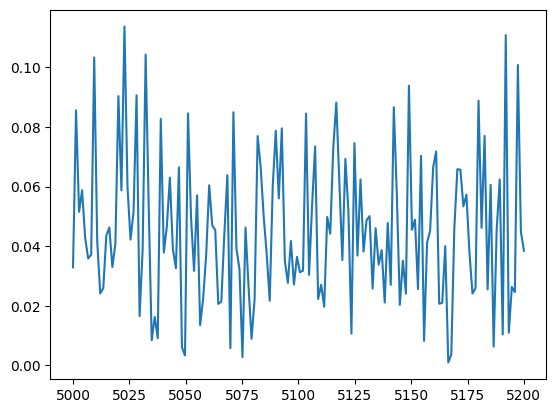

In [21]:
server_commands = {
    "operation_code": OperationCode.EXECUTE_SWEEPS,
    "cfg": config,
    "sequence": sequence,
    "qubits": [qubit],
    "sweepers": [sweeper],
}

i, q = execute(server_commands, HOST, PORT)

frequency = np.linspace(sweeper.starts[0], sweeper.stops[0], sweeper.expts)
results = np.array(i[0][0]) + 1j * np.array(q[0][0])
plt.plot(frequency, np.abs(results))